# Agrupamento de variedades de arroz

A base de dados é composta por **45** características e **2'091** entradas.


In [25]:
%%html
<link rel="stylesheet" href="./style.css">

In [26]:
from data import scaled_df
from columns import categorical_columns, numeric_columns

from kmodes.kprototypes import KPrototypes
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


# Identify indexes of categorical indexes
indexes_of_categorical_columns = [
    scaled_df.columns.get_loc(col) for col in categorical_columns
]

In [27]:
clustered_df_through_kp = scaled_df.copy()

k_prototypes_protocol = KPrototypes(n_clusters=2, random_state=42)

clusters = k_prototypes_protocol.fit_predict(
    clustered_df_through_kp, categorical=indexes_of_categorical_columns
)

# Add column describing the cluster to the database
clustered_df_through_kp["Cluster"] = clusters


Número de clusters: 2
Número de variáveis: 45

Centróides:
[['-1.0299044056978595' '-1.0299044056978595' '-1.0299044056978595'
  '-1.0299044056978595' '-1.0299044056978595' '-1.0299044056978595'
  '-1.0299044056978595' '-1.0299044056978597' '-1.0299044056978595'
  '-1.0299044056978595' '-1.0299044056978595' '0.006700107233010265'
  '-0.006700107233010265' '-0.0019331986973994144'
  '0.0019331986974208154' '-0.0077629515682384' '0.007762951568321784'
  '-0.0019331986974489134' '0.0019331986974324565' '-0.02254308547331724'
  '0.001584640831569842' '-0.011216092802271302' '0.017085377042215463'
  '-0.019521273269438318' '-0.027150253012200445' '-0.019272748007565742'
  '-0.017009275440428757' '-0.006141751724025654' '-0.021844132411667373'
  '-0.004108464406821229' '-0.026151890425959896' '0.017448764232034182'
  '-3.24369218660711e-05' '-0.0020663729695657596' '0.015620192427443749'
  '197.9243119266055' '12608.915137614678' 'Sankarapuram' 'ponmani'
  'clay' 'dry' 'SSE' 'W' 'SE' 'NW']
 

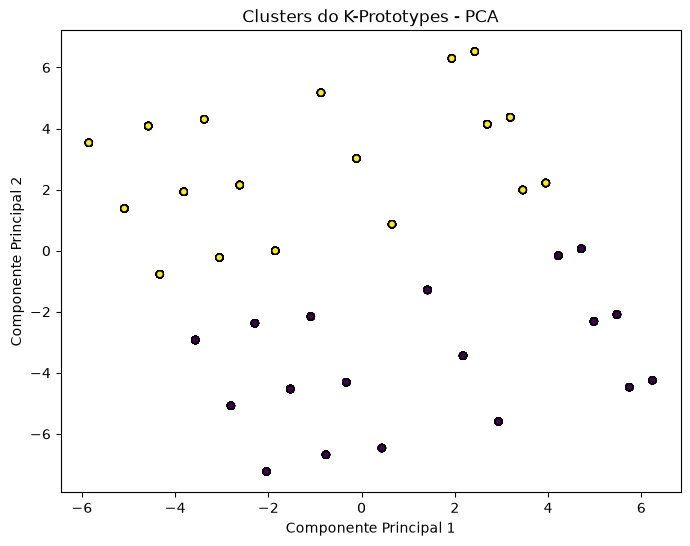

In [28]:
centroides = k_prototypes_protocol.cluster_centroids_

print("Número de clusters:", k_prototypes_protocol.n_clusters)
print("Número de variáveis:", len(clustered_df_through_kp.columns) - 1)

print("\nCentróides:")
print(centroides)


pca = PCA(n_components=2)

xn = pca.fit_transform(clustered_df_through_kp[numeric_columns])
plt.figure(figsize=(8, 6))

plt.scatter(xn[:, 0], xn[:, 1], marker="o", c=clusters, s=25, edgecolor="k")

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Clusters do K-Prototypes - PCA")

plt.show()